# Winds (Part 1) - Climatology

## Global Inset

### Global Importation

In [86]:
# Shape modules 
from collections import defaultdict

# Computational modules 
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

### Load Raw Data (ESM-piCTL)

In [87]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-piCTL'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_0 = ["ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_210001-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_225001-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_235001-244912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_245001-250012.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_250101-254912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_255001-264912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_265001-274912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_275001-279912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_280001-280012.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_280101-284912.nc",
               "ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_285001-289912.nc"]

files_ens_0 = {}
for expe in tqdm(file_list_0):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_0[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|███████████████████████████| 12/12 [00:00<00:00, 18.92it/s]


### Load Raw Data (ESM-up2p0)

In [88]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-up2p0'
config_1 = 'r1i1p1f1'
var = 'ua'
sub1 = 'gn'
sub2 = 'v20241216'
file_list_1 = ["ua_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_185001-194912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_195001-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_205001-213912.nc"]

files_ens_1 = {}
for expe in tqdm(file_list_1):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}")
    files_ens_1[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 15.75it/s]


In [89]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20260623'
file_list_2 = ["ua_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_185001-194912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_195001-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_205001-213912.nc"]

files_ens_2 = {}
for expe in tqdm(file_list_2):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}")
    files_ens_2[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 18.41it/s]


In [90]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20260623'
file_list_3 = ["ua_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_185001-194912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_195001-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_205001-213912.nc"]

files_ens_3 = {}
for expe in tqdm(file_list_3):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}")
    files_ens_3[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 15.66it/s]


In [91]:
config_4 = 'r4i1p1f1'
sub5 = 'v20260623'
file_list_4 = ["ua_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_185001-194912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_195001-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_205001-213912.nc"]

files_ens_4 = {}
for expe in tqdm(file_list_4):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}")
    files_ens_4[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 19.71it/s]


### Load Raw Data (Branch-Runs)

In [92]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl2p0'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_5 = ["ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_194401-194912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_195001-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_205001-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_225001-234312.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_234401-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_235001-244412.nc"]

files_ens_5 = {}
for expe in tqdm(file_list_5):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_5[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 7/7 [00:00<00:00, 15.02it/s]


In [93]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl3p0'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_6 = ["ua_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_199201-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_205001-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_225001-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_235001-241112.nc"]

files_ens_6 = {}
for expe in tqdm(file_list_6):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_6[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 5/5 [00:00<00:00, 11.18it/s]


In [94]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl4p0'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_7 = ["ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_204401-204912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_205001-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_225001-234312.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_234401-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_235001-244912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_245001-254412.nc"]

files_ens_7 = {}
for expe in tqdm(file_list_7):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_7[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 7/7 [00:00<00:00, 63.32it/s]


In [95]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl5p0'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_8 = ["ua_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_208201-209212.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_209301-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_225001-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_235001-239412.nc"]

files_ens_8 = {}
for expe in tqdm(file_list_8):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_8[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 5/5 [00:00<00:00, 77.67it/s]


In [96]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl6p0'
config_1 = 'r1i1p1f1'
var = 'ua'
file_list_9 = ["ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_213701-214912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_215001-224912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_225001-234912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_235001-244912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_245001-254912.nc",
               "ua_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_255001-263912.nc"]

files_ens_9 = {}
for expe in tqdm(file_list_9):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_9[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 6/6 [00:00<00:00, 22.70it/s]


### Standardise Coordinates

In [97]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Filter Data and Merge Time

In [98]:
files_ens_0['ua_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_210001-214912.nc']

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 600, bnds: 2, plev: 19, lat: 145, lon: 192)
Coordinates:
  * time       (time) object 5kB 2100-01-16 00:00:00 ... 2149-12-16 00:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 10kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(145, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    ua         (time, plev, lat, lon) float32 1GB dask.array<chunksize=(1, 19, 145, 192), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-07-03T17:15:05Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    tracking_id:           GCMODELDEV/bbc75fbd-64b4-453d-a7cc-005219fd880f
    variable_id:           ua
    variable_name:         ua
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3

In [110]:
# We need to filter the data before merging time.
# The dataset is huge so it can be computationally expensive to concatenate... 
space_filtered_piCTL = {}

path_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Winds/'

# Set extent
lonmin, lonmax = -20, 20
latmin, latmax = -5, 20
pmin, pmax = 10000, 100000         # Pressure in the data is in Pascals

for expe in files_ens_0:
    data = standardise_coordinates(files_ens_0[expe])
    filtered_data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_piCTL[expe] = filtered_data

In [100]:
space_filtered_up2p0_ens1 = {}
space_filtered_up2p0_ens2 = {}
space_filtered_up2p0_ens3 = {}
space_filtered_up2p0_ens4 = {}

for expe in files_ens_1:
    data = standardise_coordinates(files_ens_1[expe])
    filtered_data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_up2p0_ens1[expe] = filtered_data

In [101]:
for expe in files_ens_2:
    data = standardise_coordinates(files_ens_2[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_up2p0_ens2[expe] = data

In [102]:
for expe in files_ens_3:
    data = standardise_coordinates(files_ens_3[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_up2p0_ens3[expe] = data

In [103]:
for expe in files_ens_4:
    data = standardise_coordinates(files_ens_4[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_up2p0_ens4[expe] = data

In [104]:
space_filtered_swl2p0 = {}
space_filtered_swl3p0 = {}
space_filtered_swl4p0 = {}
space_filtered_swl5p0 = {}
space_filtered_swl6p0 = {}

for expe in files_ens_5:
    data = standardise_coordinates(files_ens_5[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_swl2p0[expe] = data

In [20]:
for expe in files_ens_6:
    data = standardise_coordinates(files_ens_6[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_swl3p0[expe] = data

In [21]:
for expe in files_ens_7:
    data = standardise_coordinates(files_ens_7[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_swl4p0[expe] = data

In [22]:
for expe in files_ens_8:
    data = standardise_coordinates(files_ens_8[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_swl5p0[expe] = data

In [105]:
for expe in files_ens_9:
    data = standardise_coordinates(files_ens_9[expe])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax), plev=slice(pmax, pmin))
    space_filtered_swl6p0[expe] = data

### Load Merged piCTL Data

In [109]:
model_short = 'UKESM_ramp_up'

path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"
filename = "time_merged.nc"
controlled = ['esm-piCTL']

controlled_run_file = {}

for ens in controlled:
    controlled_run_file[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

In [25]:
controlled_run_file[controlled[0]]['ua'].values[:1]

array([[[[ -3.4587402 ,  -3.2490234 ,  -3.0625    , ...,          nan,
                   nan,          nan],
         [ -2.817627  ,  -2.6582031 ,  -2.5864258 , ...,          nan,
                   nan,          nan],
         [ -2.5500488 ,  -2.5766602 ,  -2.6850586 , ...,          nan,
                   nan,          nan],
         ...,
         [ -7.2910156 ,  -7.2348633 ,  -8.215576  , ...,          nan,
                   nan,          nan],
         [ -7.2578125 ,  -7.1901855 ,  -8.018799  , ...,          nan,
                   nan,          nan],
         [ -7.190674  ,  -6.779785  ,  -6.789923  , ...,          nan,
                   nan,          nan]],

        [[ -3.6843262 ,  -3.3874512 ,  -3.1269531 , ...,   2.493164  ,
            2.0541992 ,   2.3625488 ],
         [ -3.2546387 ,  -3.010254  ,  -2.8596191 , ...,   2.2231445 ,
            2.6054688 ,   2.6394043 ],
         [ -3.2456055 ,  -3.180664  ,  -3.1699219 , ...,   1.6625977 ,
            2.2456055 ,   1.84594

### Load Merged Ramp-Up Data (up2p0)

In [26]:
members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

ramp_up_model_files = {}

for ens in members:
    ramp_up_model_files[ens] = xr.open_mfdataset(f'{path_files}esm-up2p0_{ens}_{filename}', combine='by_coords', use_cftime=True)

In [27]:
# Data quality check.
ramp_up_model_files[members[0]]

<xarray.Dataset> Size: 76MB
Dimensions:    (time: 3480, bnds: 2, latitude: 21, longitude: 21, plev: 12)
Coordinates:
  * time       (time) object 28kB 1850-01-16 00:00:00 ... 2139-12-16 00:00:00
  * plev       (plev) float64 96B 1e+05 9.25e+04 8.5e+04 ... 2e+04 1.5e+04 1e+04
  * latitude   (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0
  * longitude  (longitude) float64 168B -18.75 -16.88 -15.0 ... 15.0 16.88 18.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 56kB dask.array<chunksize=(3480, 2), meta=np.ndarray>
    lat_bnds   (time, latitude, bnds) float64 1MB dask.array<chunksize=(3480, 21, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, bnds) float64 1MB dask.array<chunksize=(3480, 21, 2), meta=np.ndarray>
    ua         (time, plev, latitude, longitude) float32 74MB dask.array<chunksize=(1740, 6, 11, 11), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-02-26T18:01:16Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    tracking_id:           GCMODELDEV/3257b1cf-b6d1-4467-ac27-b39a150e8a8f
    variable_id:           ua
    variable_name:         ua
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3

### Load Merged Branch-Run Data (esm-swl)

In [111]:
ensemble = 'r1i1p1f1'
level_list = ["esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

filename = 'time_merged.nc'
level_run_model_1_files = {}

for scenario in level_list:
    level_run_model_1_files[scenario] = xr.open_mfdataset(f'{path_files}{scenario}_{filename}', combine='by_coords', use_cftime=True)
    print(f'\n{scenario} Branch Off Start Date: ', level_run_model_1_files[scenario]['time'].min().item())
    print(f'{scenario} Branch Off End Date: ', level_run_model_1_files[scenario]['time'].max().item())


esm-swl2p0 Branch Off Start Date:  1944-01-16 00:00:00
esm-swl2p0 Branch Off End Date:  2444-12-16 00:00:00

esm-swl3p0 Branch Off Start Date:  1992-01-16 00:00:00
esm-swl3p0 Branch Off End Date:  2411-12-16 00:00:00

esm-swl4p0 Branch Off Start Date:  2044-01-16 00:00:00
esm-swl4p0 Branch Off End Date:  2544-12-16 00:00:00

esm-swl5p0 Branch Off Start Date:  2082-01-16 00:00:00
esm-swl5p0 Branch Off End Date:  2394-12-16 00:00:00

esm-swl6p0 Branch Off Start Date:  2137-01-16 00:00:00
esm-swl6p0 Branch Off End Date:  2639-12-16 00:00:00


In [112]:
level_run_model_1_files[level_list[0]]['ua'].values[:1]

array([[[[ -5.2314453 ,  -5.0356445 ,  -4.8015137 , ...,          nan,
                   nan,          nan],
         [ -4.57959   ,  -4.428955  ,  -4.302246  , ...,          nan,
                   nan,          nan],
         [ -3.7575684 ,  -3.5959473 ,  -3.5222168 , ...,          nan,
                   nan,          nan],
         ...,
         [ -5.8637695 ,  -4.4750977 ,  -4.373047  , ...,          nan,
                   nan,          nan],
         [ -6.1186523 ,  -4.751953  ,  -4.7530293 , ...,          nan,
                   nan,          nan],
         [ -6.3151855 ,  -4.8774414 ,  -5.5253563 , ...,          nan,
                   nan,          nan]],

        [[ -5.382324  ,  -5.1520996 ,  -4.849365  , ...,   3.909668  ,
            2.5512695 ,   2.2541504 ],
         [ -4.934082  ,  -4.7736816 ,  -4.5456543 , ...,   3.9470215 ,
            3.7468262 ,   3.3105469 ],
         [ -4.2783203 ,  -4.126709  ,  -3.9667969 , ...,   3.821289  ,
            4.0166016 ,   3.44018

### Standardise Coordinates

In [29]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Implementation 1a (Seasonal Mean, Over Time)

In [30]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

### Implementation 1b (Regional Seasonal Mean, Over Time)

In [31]:
def seasonal_area_weighted_avg(data, lonmin, lonmax, latmin, latmax):

    # Standardise coordinates
    data = standardise_coordinates(data)
    
    # 1. Spatial filter
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax))

    # 2. Masking the ocean.
    data = data.where(ocean_masked)
    
    # 3. Seasonal average (MJJAS)
    data = data.sel(time=data.time.dt.month.isin([5, 6, 7, 8, 9]))
    seasonal = data.groupby('time.year').mean('time')

    # 4. Area-weighted average
    lat_rad = np.radians(seasonal['latitude'])
    lat_weights = np.cos(lat_rad)

    # Broadcast latitude weights over the spatial dimensions
    weights = lat_weights.broadcast_like(seasonal)

    # Account for NaNs / land-sea mask
    valid_mask = ~np.isnan(seasonal)
    weights_masked = weights.where(valid_mask)

    # Normalise weights for each year
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])

    # Area-weighted mean
    weighted_avg = ((seasonal * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum)
    return weighted_avg

### Compute Ramp-up Ensemble Mean

In [32]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='ua'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [33]:
time_series_ramp_up_ens_avg = compute_ensemble_mean(members, ramp_up_model_files)
time_series_ramp_up_ens_avg

<xarray.DataArray 'ua' (time: 3480, plev: 12, latitude: 21, longitude: 21)> Size: 74MB
dask.array<mean_agg-aggregate, shape=(3480, 12, 21, 21), dtype=float32, chunksize=(1740, 6, 11, 11), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 28kB 1850-01-16 00:00:00 ... 2139-12-16 00:00:00
  * plev       (plev) float64 96B 1e+05 9.25e+04 8.5e+04 ... 2e+04 1.5e+04 1e+04
  * latitude   (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0
  * longitude  (longitude) float64 168B -18.75 -16.88 -15.0 ... 15.0 16.88 18.75

## Cross-Section Profile and Differences

### Filter Ensemble Data (Climatology)

In [34]:
# Now we are interested in the plus-or-minus 15 years relative to the branch-off point.
# Period varies with level.
# We are only looking at ensemble r1p1i1f1 due to data incompleteness.
ramp_up_filtered_files_ens1 = {}
ramp_up_filtered_files_ens2 = {}
ramp_up_filtered_files_ens3 = {}
ramp_up_filtered_files_ens4 = {}

start_date_list = ["1904-01-01", "1929-01-01", "1977-01-01", "2029-01-01", "2077-01-01", "2129-01-01"]
end_date_list = ["1935-01-01", "1960-01-01", "2008-01-01", "2060-01-01", "2108-01-01", "2160-01-01"]

# Convert units within the loop when saving the file.
for ens in members:
    for (start, end, scenario) in zip(start_date_list, end_date_list, level_list):
        if ens == 'r1i1p1f1':
            ramp_up_filtered_files_ens1[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            ramp_up_filtered_files_ens1[scenario].to_netcdf(save_name)
        elif ens == 'r2i1p1f1':
            ramp_up_filtered_files_ens2[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            ramp_up_filtered_files_ens2[scenario].to_netcdf(save_name)
        elif ens == 'r3i1p1f1':
            ramp_up_filtered_files_ens3[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            ramp_up_filtered_files_ens3[scenario].to_netcdf(save_name)
        else:
            ramp_up_filtered_files_ens4[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            ramp_up_filtered_files_ens4[scenario].to_netcdf(save_name)

In [35]:
# Check data quality.
ramp_up_filtered_files = {member: {} for member in members}

for member in members:
    for scenario in level_list:
        ramp_up_filtered_files[member][scenario] = xr.open_mfdataset(f'{path_files}{member}_{scenario}_branch_off_point_filtered.nc', combine='by_coords', use_cftime=True)

print('Start Date: ', ramp_up_filtered_files_ens1[level_list[0]]['time'].min().item())
print('End Date: ', ramp_up_filtered_files_ens1[level_list[0]]['time'].max().item())
print('\n', ramp_up_filtered_files_ens1[level_list[0]]['ua'].values[:1])

Start Date:  1904-01-16 00:00:00
End Date:  1934-12-16 00:00:00

 [[[[ -6.60083    -6.4438477  -6.1584473 ...         nan         nan
            nan]
   [ -5.800049   -5.7495117  -5.541748  ...         nan         nan
            nan]
   [ -4.9729004  -5.008789   -4.83374   ...         nan         nan
            nan]
   ...
   [ -5.972412   -6.465576   -6.769043  ...         nan         nan
            nan]
   [ -6.1728516  -6.6362305  -6.6450195 ...         nan         nan
            nan]
   [ -6.1518555  -6.6115723  -7.312725  ...         nan         nan
            nan]]

  [[ -7.151367   -6.8916016  -6.5236816 ...   3.1591797   1.6047363
      1.3937988]
   [ -6.4882812  -6.3569336  -6.0356445 ...   2.8769531   2.1572266
      1.6748047]
   [ -5.802246   -5.7297363  -5.4143066 ...   2.3874512   1.9350586
      1.2770996]
   ...
   [ -5.6723633  -7.0114746  -8.024658  ...  -9.435547  -12.098633
    -14.028076 ]
   [ -5.1066895  -6.635498   -7.9782715 ...  -3.6655273  -5.8564453
 

In [36]:
# No need to filter piCTL data.
# Recall variable as controlled_run_file[controlled[0]]

ramp_up_filtered_piCTL = {}

ramp_up_filtered_piCTL['piCTL'] = controlled_run_file[controlled[0]]
ramp_up_filtered_piCTL['piCTL']['ua'].values[:1]

array([[[[ -3.4587402 ,  -3.2490234 ,  -3.0625    , ...,          nan,
                   nan,          nan],
         [ -2.817627  ,  -2.6582031 ,  -2.5864258 , ...,          nan,
                   nan,          nan],
         [ -2.5500488 ,  -2.5766602 ,  -2.6850586 , ...,          nan,
                   nan,          nan],
         ...,
         [ -7.2910156 ,  -7.2348633 ,  -8.215576  , ...,          nan,
                   nan,          nan],
         [ -7.2578125 ,  -7.1901855 ,  -8.018799  , ...,          nan,
                   nan,          nan],
         [ -7.190674  ,  -6.779785  ,  -6.789923  , ...,          nan,
                   nan,          nan]],

        [[ -3.6843262 ,  -3.3874512 ,  -3.1269531 , ...,   2.493164  ,
            2.0541992 ,   2.3625488 ],
         [ -3.2546387 ,  -3.010254  ,  -2.8596191 , ...,   2.2231445 ,
            2.6054688 ,   2.6394043 ],
         [ -3.2456055 ,  -3.180664  ,  -3.1699219 , ...,   1.6625977 ,
            2.2456055 ,   1.84594

### Compute Seasonal Average

In [37]:
# piCTL
seas_avg_piCTL = {}

data = ramp_up_filtered_piCTL['piCTL']
seas_avg_piCTL['piCTL'] = seasonal_average_over_years_customed_MJJAS(data)

In [38]:
seas_avg_piCTL['piCTL']['ua'].values[:1]

array([[[[-7.305664  , -7.174707  , -7.037988  , ...,         nan,
                  nan,         nan],
         [-6.6922364 , -6.63208   , -6.53457   , ...,         nan,
                  nan,         nan],
         [-5.86167   , -5.877002  , -5.8049803 , ...,         nan,
                  nan,         nan],
         ...,
         [ 0.71254885,  3.274121  ,  4.0237336 , ...,         nan,
                  nan,         nan],
         [-0.43305665,  1.9040039 ,  2.4539154 , ...,         nan,
                  nan,         nan],
         [-1.6562011 ,  0.28051758, -1.3477616 , ...,         nan,
                  nan,         nan]],

        [[-7.472705  , -7.300879  , -7.123389  , ...,  2.7406738 ,
          -0.02294922, -1.5305665 ],
         [-6.989258  , -6.872119  , -6.722705  , ...,  3.0821776 ,
           1.0969727 , -0.16030273],
         [-6.3335447 , -6.27124   , -6.1405764 , ...,  2.7867675 ,
           1.9848144 ,  1.2806641 ],
         ...,
         [-2.153955  , -0.88500977

In [39]:
# Ramp-Up
seas = 'MJJAS'
members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']
level_list = ["esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

seas_avg_model = {member: {} for member in members}

# Compute seasonal average for every ensemble and scenario
for member in members:
    for scenario in level_list:
        data = ramp_up_filtered_files[member][scenario]
        seas_avg_model[member][scenario] = seasonal_average_over_years_customed_MJJAS(data).mean('year')

### Compute Zonal Mean

In [40]:
zonal_mean_ramp_up = {member: {} for member in members}

# Note that we have filtered the data in the preprocessing stage.
for member in members:
    for scenario in level_list:
        zonal_mean_ramp_up[member][scenario] = seas_avg_model[member][scenario].mean('longitude')

In [41]:
zonal_mean_ramp_up[member][scenario]['ua'].values[:1]

array([[-3.2278833 , -2.9671054 , -2.2163718 , -1.3182162 , -0.2156393 ,
         1.0548203 ,  2.3564248 ,  3.4888291 ,  3.7047207 ,  3.8179038 ,
         4.1191936 ,  3.661882  ,  3.8670971 ,  4.238323  ,  5.139625  ,
         5.8323107 ,  5.8714194 ,  4.6509247 ,  3.9982934 ,  1.9255766 ,
         0.07051305]], dtype=float32)

### Compute Ensemble Mean

In [42]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='ua'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [43]:
climatology_ens_mean = {}

for scenario in level_list:

    # Collect this scenario from all ensemble members
    scenario_data = {ens: zonal_mean_ramp_up[ens][scenario] for ens in members}

    # Compute ensemble mean
    climatology_ens_mean[scenario] = compute_ensemble_mean(members, scenario_data)

In [44]:
climatology_ens_mean[scenario].values[:1]

array([[-3.2254188 , -2.9529228 , -2.1868877 , -1.2748916 , -0.16722012,
         1.1076701 ,  2.412286  ,  3.5419106 ,  3.911075  ,  3.8366873 ,
         4.150782  ,  3.6928449 ,  3.883682  ,  4.247858  ,  5.162023  ,
         5.8364296 ,  5.7522097 ,  4.6816735 ,  3.9819183 ,  1.9240043 ,
         0.16407937]], dtype=float32)

### Compute Difference

In [45]:
# Compare ensemble mean with piCTL
def compute_anomaly(ens_mean_data, piCTL_data):
    anomaly = ens_mean_data - piCTL_data
    return anomaly

In [46]:
anomaly_data = {}

for scenario in level_list:
    ens_mean_data = climatology_ens_mean[scenario]
    piCTL_data = seas_avg_piCTL['piCTL']['ua'].mean('longitude').mean('year')
    anomaly_data[scenario] = compute_anomaly(ens_mean_data, piCTL_data)

In [47]:
anomaly_data[scenario].values

array([[ 0.71674466,  0.81198287,  0.857919  ,  0.9139869 ,  1.0198674 ,
         1.089462  ,  1.1046975 ,  1.0912197 ,  0.8965199 ,  0.7781894 ,
         0.6464107 ,  0.39820004,  0.24513721,  0.56067467,  0.7201128 ,
         0.8194933 ,  1.1016164 ,  0.88517165,  1.2031825 ,  0.7309991 ,
         0.97185737],
       [ 0.8068762 ,  0.908499  ,  1.0087025 ,  1.089916  ,  1.1061364 ,
         1.0636895 ,  1.0128317 ,  1.0032806 ,  0.914974  ,  0.7456982 ,
         0.6200514 ,  0.6300266 ,  0.72977614,  0.9052243 ,  1.1944377 ,
         1.4944408 ,  1.6795336 ,  1.6714706 ,  1.4487274 ,  1.1178524 ,
         0.8176961 ],
       [ 1.0303667 ,  1.211025  ,  1.2906646 ,  1.230001  ,  1.1131873 ,
         1.0443537 ,  1.0139946 ,  0.9365106 ,  0.84782034,  0.8378148 ,
         0.91214454,  1.0245038 ,  1.1242349 ,  1.240982  ,  1.4018466 ,
         1.5190976 ,  1.5101929 ,  1.3871195 ,  1.2004507 ,  0.99060154,
         0.7791517 ],
       [-0.04337168,  0.0756588 ,  0.19899702,  0.31559372

### Implementation 1b (Ramp-Up Cross Section)

In [140]:
def ramp_up_cross_sections(climatology_data, anomaly_data, level_list, vmin_clim, vmax_clim, vmin_anom, vmax_anom,
                           cbar_label_clim, cbar_label_anom, palette_clim, palette_anom, Save, filename):

    fig, axes = plt.subplots(5, 2, figsize=(22, 26), constrained_layout=True)

    # Discrete colour levels
    levels_clim = np.arange(vmin_clim, vmax_clim, 0.25)
    levels_anom = np.arange(vmin_anom, vmax_anom, 0.2)
    
    for i, scenario in enumerate(level_list):

        # Left-Column - MEAN CLIMATOLOGY
        data = climatology_data[scenario]

        if 'plev' in data.coords:
            data = data.rename({'plev': 'pressure_level'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('pressure_level', 'latitude')
        
        lat = data['latitude'].values
        pressure = data['pressure_level'].values / 100        # Convert units from Pa to hPa.

        # Latitude-pressure grid
        lat2d, pressure2d = np.meshgrid(lat, pressure)

        # Plot zonal wind
        contour_clim = axes[i, 0].contourf(lat2d, pressure2d, data.values, levels=levels_clim,
                                           cmap=palette_clim, extend='neither')
    
        # Add contour lines every 2 m/s
        contour_lines = axes[i, 0].contour(lat2d, pressure2d, data.values, levels=np.arange(-15, 15, 2),
                                           colors='purple', linewidths=2.5)

        # Label contour lines
        axes[i, 0].clabel(contour_lines, inline=True, fontsize=9, fmt='%d')
        axes[i, 0].invert_yaxis()
        axes[i, 0].set_xlabel('Latitude (°)', fontsize=10)
        axes[i, 0].set_ylabel('Pressure Level (hPa)', fontsize=10)
        axes[i, 0].grid(True, linestyle='--', alpha=0.5)
        axes[i, 0].set_title(f'{scenario} Branch-Off Point (± 15 years) Ensemble Mean Wind Speed', fontsize=14)

        # Right-Column - ANOMALY
        
        data = anomaly_data[scenario]

        if 'plev' in data.coords:
            data = data.rename({'plev': 'pressure_level'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('pressure_level', 'latitude')
        
        lat = data['latitude'].values
        pressure = data['pressure_level'].values / 100

        # Latitude-pressure grid
        lat2d, pressure2d = np.meshgrid(lat, pressure)

        # Plot zonal wind
        contour_anom = axes[i, 1].contourf(lat2d, pressure2d, data.values, levels=levels_anom,
                                           cmap=palette_anom, extend='neither')

        # Add contour lines every 2 m/s
        contour_lines = axes[i, 1].contour(lat2d, pressure2d, data.values, levels=np.arange(-7, 7, 0.5),
                                           colors='black', linewidths=2.5)

        # Label contour lines
        axes[i, 1].clabel(contour_lines, inline=True, fontsize=9, fmt='%.1f')
        axes[i, 1].invert_yaxis()
        axes[i, 1].set_xlabel('Latitude (°)', fontsize=10)
        axes[i, 1].set_ylabel('Pressure Level (hPa)', fontsize=10)
        axes[i, 1].grid(True, linestyle='--', alpha=0.5)
        axes[i, 1].set_title(f'{scenario} Branch-Off Point Difference Relative to piCTL Mean', fontsize=14)

    # Colourbars
    cbar_clim = fig.colorbar(contour_clim, ax=axes[:, 0], orientation='horizontal', fraction=0.02,
                             pad=0.03, ticks=np.arange(vmin_clim, vmax_clim, 2))
    cbar_clim.set_label(cbar_label_clim, fontsize=14)

    cbar_anom = fig.colorbar(contour_anom, ax=axes[:, 1], orientation='horizontal', fraction=0.02,
                             pad=0.03, ticks=np.arange(vmin_anom, vmax_anom, 1))
    cbar_anom.set_label(cbar_label_anom, fontsize=14)
    
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

In [48]:
for scenario in level_list:
    print(scenario, "Climatology:", climatology_ens_mean[scenario].min().compute().values,
          "to", climatology_ens_mean[scenario].max().compute().values)

esm-swl2p0 Climatology: -10.296684 to 12.04405
esm-swl3p0 Climatology: -10.258754 to 12.343698
esm-swl4p0 Climatology: -10.223871 to 12.804365
esm-swl5p0 Climatology: -10.094693 to 13.330798
esm-swl6p0 Climatology: -10.213852 to 14.302436


### Plot

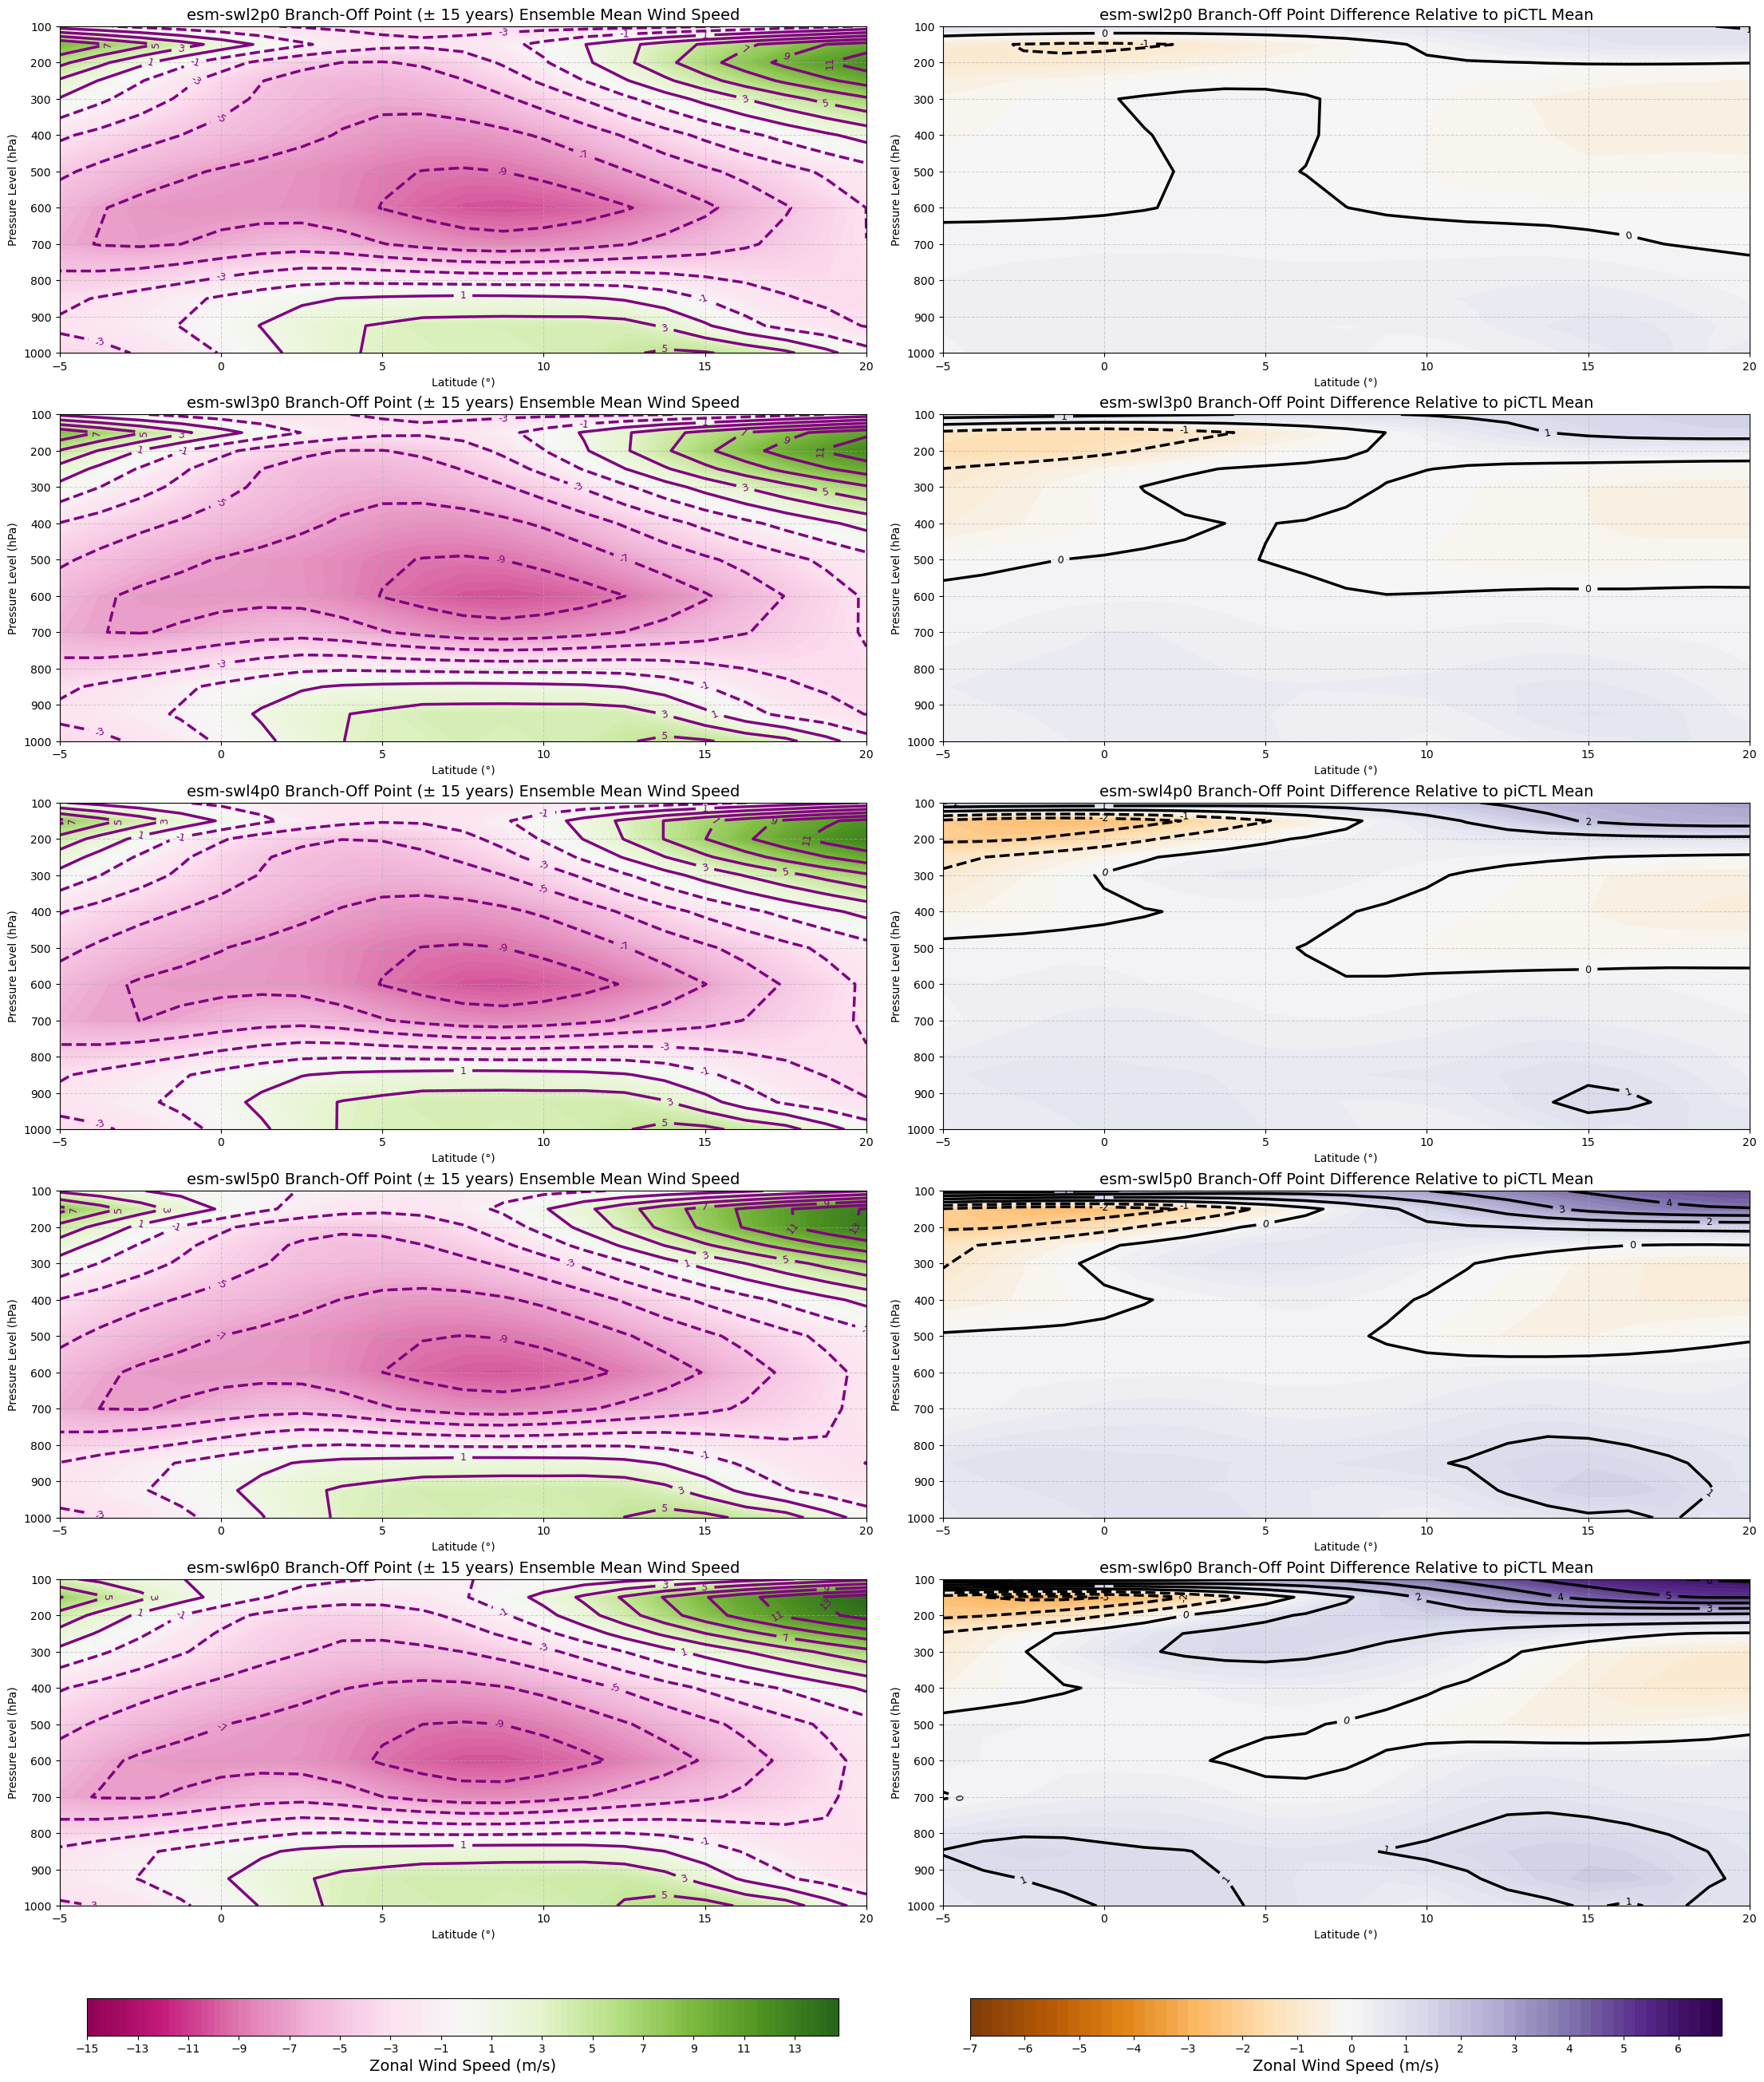

In [144]:
# Colour palette parameters.
vmin_clim = -15
vmax_clim = 15

vmin_anom = -7
vmax_anom = 7

# Palettes for colour bars
palette_clim = 'PiYG'
palette_anom = 'PuOr'

# Colourbar labels
cbar_label_clim = 'Zonal Wind Speed (m/s)'
cbar_label_anom = 'Zonal Wind Speed (m/s)'

Save = True
path_figure = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Winds'
filename = f'{path_figure}/climatology_difference_branch-off_points.png'

ramp_up_cross_sections(climatology_ens_mean, anomaly_data, level_list, vmin_clim, vmax_clim,
                       vmin_anom, vmax_anom, cbar_label_clim, cbar_label_anom, palette_clim, palette_anom,
                       Save, filename)

## Net-Zero Run Analysis

### Compute Seasonal Average

In [113]:
# Ramp-Up
seas = 'MJJAS'
members = ['r1i1p1f1']
level_list = ["esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

seas_avg_branch_run = {member: {} for member in members}

# Compute seasonal average for every ensemble and scenario
for member in members:
    for scenario in level_list:
        data = level_run_model_1_files[scenario]
        seas_avg_branch_run[member][scenario] = seasonal_average_over_years_customed_MJJAS(data)

In [118]:
# Data quality check.
seas_avg_branch_run[member][level_list[0]]['ua'].values[:1]

array([[[[-7.454248  , -7.234961  , -6.9790525 , ...,         nan,
                  nan,         nan],
         [-6.96543   , -6.7371583 , -6.4779787 , ...,         nan,
                  nan,         nan],
         [-6.2529297 , -6.0103517 , -5.7523437 , ...,         nan,
                  nan,         nan],
         ...,
         [ 0.6357422 ,  3.4649901 ,  4.4876776 , ...,         nan,
                  nan,         nan],
         [-0.6568359 ,  1.9987793 ,  2.7961137 , ...,         nan,
                  nan,         nan],
         [-1.8999023 ,  0.23715821,  1.0202855 , ...,         nan,
                  nan,         nan]],

        [[-7.6370606 , -7.353223  , -7.060254  , ...,  4.319092  ,
           2.3331542 ,  0.2440918 ],
         [-7.304297  , -7.019629  , -6.7116213 , ...,  4.529883  ,
           3.577539  ,  1.9570312 ],
         [-6.8111815 , -6.548047  , -6.2216797 , ...,  4.308838  ,
           4.1729493 ,  3.2141602 ],
         ...,
         [-1.8467773 , -0.3144043 

### Student t-Test

In [119]:
def ttest_NO_bootstrap(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    assert n_scen == n_ctl
    
    t_stat, p_value = ttest_ind(data_scen, data_piCTL, axis=0, equal_var=False)

    # Create an Xarray
    p_empirical_xr = xr.DataArray(p_value, dims=["plev", "latitude", 'longitude'],
                                  coords={"plev": data_scen["plev"],
                                          "latitude": data_scen["latitude"],
                                          "longitude": data_scen["longitude"]},
                                  name="p_value")

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()    
    return ds

### Compute Statistical Significance and Anomaly (First-Last 100 Years)

In [191]:
# Dictionary storing p-values for each level.
p_val_dict = {}
gwl_diff_dict = {}
gwl_diff_dict_clim = {}
gwl_first100yrs_dict = {}

for scenario in level_list:
    # Student-t
    data_gwl = seas_avg_branch_run[member][scenario]
    data_gwl_first100yrs = data_gwl.sel(year=slice(data_gwl['year'][0], data_gwl['year'][99]))
    data_gwl_last100yrs = data_gwl.sel(year=slice(data_gwl['year'][-100], data_gwl['year'][-1]))
    p_val_dict[scenario] = ttest_NO_bootstrap(data_gwl_first100yrs['ua'], data_gwl_last100yrs['ua'])

    # Anomaly
    # Cross Section
    anomaly_cs = data_gwl_last100yrs.mean('year').mean('longitude') - data_gwl_first100yrs.mean('year').mean('longitude')
    gwl_diff_dict[scenario] = anomaly_cs

    # Climatology
    anomaly_clim = data_gwl_last100yrs.mean('year').sel(plev=85000) - data_gwl_first100yrs.mean('year').sel(plev=85000)
    gwl_diff_dict_clim[scenario] = anomaly_clim
    
    # For contouring in climatology
    gwl_first100yrs_dict[scenario] = data_gwl_first100yrs.mean('year').sel(plev=85000)

In [192]:
for scenario in level_list:
    print(f'\nMin first100yrs Datum {scenario} =', gwl_first100yrs_dict[scenario]['ua'].min().values)
    print(f'Max first100yrs Datum {scenario} =', gwl_first100yrs_dict[scenario]['ua'].max().values)
    print(f'Min first100yrs longitude {scenario} =', gwl_first100yrs_dict[scenario]['longitude'].min().values)
    print(f'Max first100yrs longitude {scenario} =', gwl_first100yrs_dict[scenario]['longitude'].max().values)


Min first100yrs Datum esm-swl2p0 = -6.6062794
Max first100yrs Datum esm-swl2p0 = 3.19938
Min first100yrs longitude esm-swl2p0 = -18.75
Max first100yrs longitude esm-swl2p0 = 18.75

Min first100yrs Datum esm-swl3p0 = -6.480682
Max first100yrs Datum esm-swl3p0 = 3.487874
Min first100yrs longitude esm-swl3p0 = -18.75
Max first100yrs longitude esm-swl3p0 = 18.75

Min first100yrs Datum esm-swl4p0 = -6.291218
Max first100yrs Datum esm-swl4p0 = 3.76257
Min first100yrs longitude esm-swl4p0 = -18.75
Max first100yrs longitude esm-swl4p0 = 18.75

Min first100yrs Datum esm-swl5p0 = -6.073998
Max first100yrs Datum esm-swl5p0 = 3.9236114
Min first100yrs longitude esm-swl5p0 = -18.75
Max first100yrs longitude esm-swl5p0 = 18.75

Min first100yrs Datum esm-swl6p0 = -5.808237
Max first100yrs Datum esm-swl6p0 = 4.1996107
Min first100yrs longitude esm-swl6p0 = -18.75
Max first100yrs longitude esm-swl6p0 = 18.75


### Implementation 2a (Cross-Section)

In [142]:
def net_zero_cs(diff_data, level_list, vmin, vmax, latmin, latmax, pmin, pmax, cbar_label,
                palette, Save, filename, p_values):

    fig, axes = plt.subplots(2, 3, figsize=(24, 14), constrained_layout=True)

    axes = axes.flatten()

    # Discrete colour levels
    levels = np.arange(vmin, vmax, 0.05)

    for i, scenario in enumerate(level_list):

        data = diff_data[scenario]['ua']

        if 'plev' in data.coords:
            data = data.rename({'plev': 'pressure_level'})
        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('pressure_level', 'latitude')
        
        lat = data['latitude'].values
        pressure = data['pressure_level'].values / 100

        # Latitude-pressure grid
        lat2d, pressure2d = np.meshgrid(lat, pressure)

        # Plot zonal wind
        contour = axes[i].contourf(lat2d, pressure2d, data.values, levels=levels,
                                   cmap=palette, extend='neither')
    
        # Add contour lines every 5 m/s
        contour_lines = axes[i].contour(lat2d, pressure2d, data.values, levels=np.arange(-2, 2, 0.25),
                                        colors='black', linewidths=2.5)

        # Significance stippling
        if p_values[scenario]['p_value'] is not None:
            pvals = p_values[scenario]['p_value'].mean('longitude')
            sig_mask = pvals.values <= 0.05
            hatch_mask = np.where(sig_mask, 1, np.nan)
            axes[i].pcolor(lat2d, pressure2d, hatch_mask, hatch='..', alpha=0.0, zorder=3)

        # Formatting
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
        # Label contour lines
        # Set labels and axes
        axes[i].clabel(contour_lines, inline=True, fontsize=10, fmt='%.1f')
        axes[i].invert_yaxis()
        axes[i].set_xlim(latmin, latmax)
        axes[i].set_ylim(pmax, pmin)
        axes[i].set_xlabel('Latitude (°)', fontsize=10)
        axes[i].set_ylabel('Pressure Level (hPa)', fontsize=10)
        axes[i].set_title(f'{scenario} Difference: Last 100 Years - First 100 Years',
                          fontsize=14)

    # Turn off the last panel.
    for j in range(len(level_list), len(axes)):
        axes[j].axis('off')
    
    # One shared colourbar for all maps
    # Colourbars
    cbar = fig.colorbar(contour, ax=axes, orientation='horizontal', fraction=0.04, pad=0.03,
                        ticks=np.arange(vmin, vmax, 0.5))
    cbar.set_label(cbar_label, fontsize=14)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Plot Difference

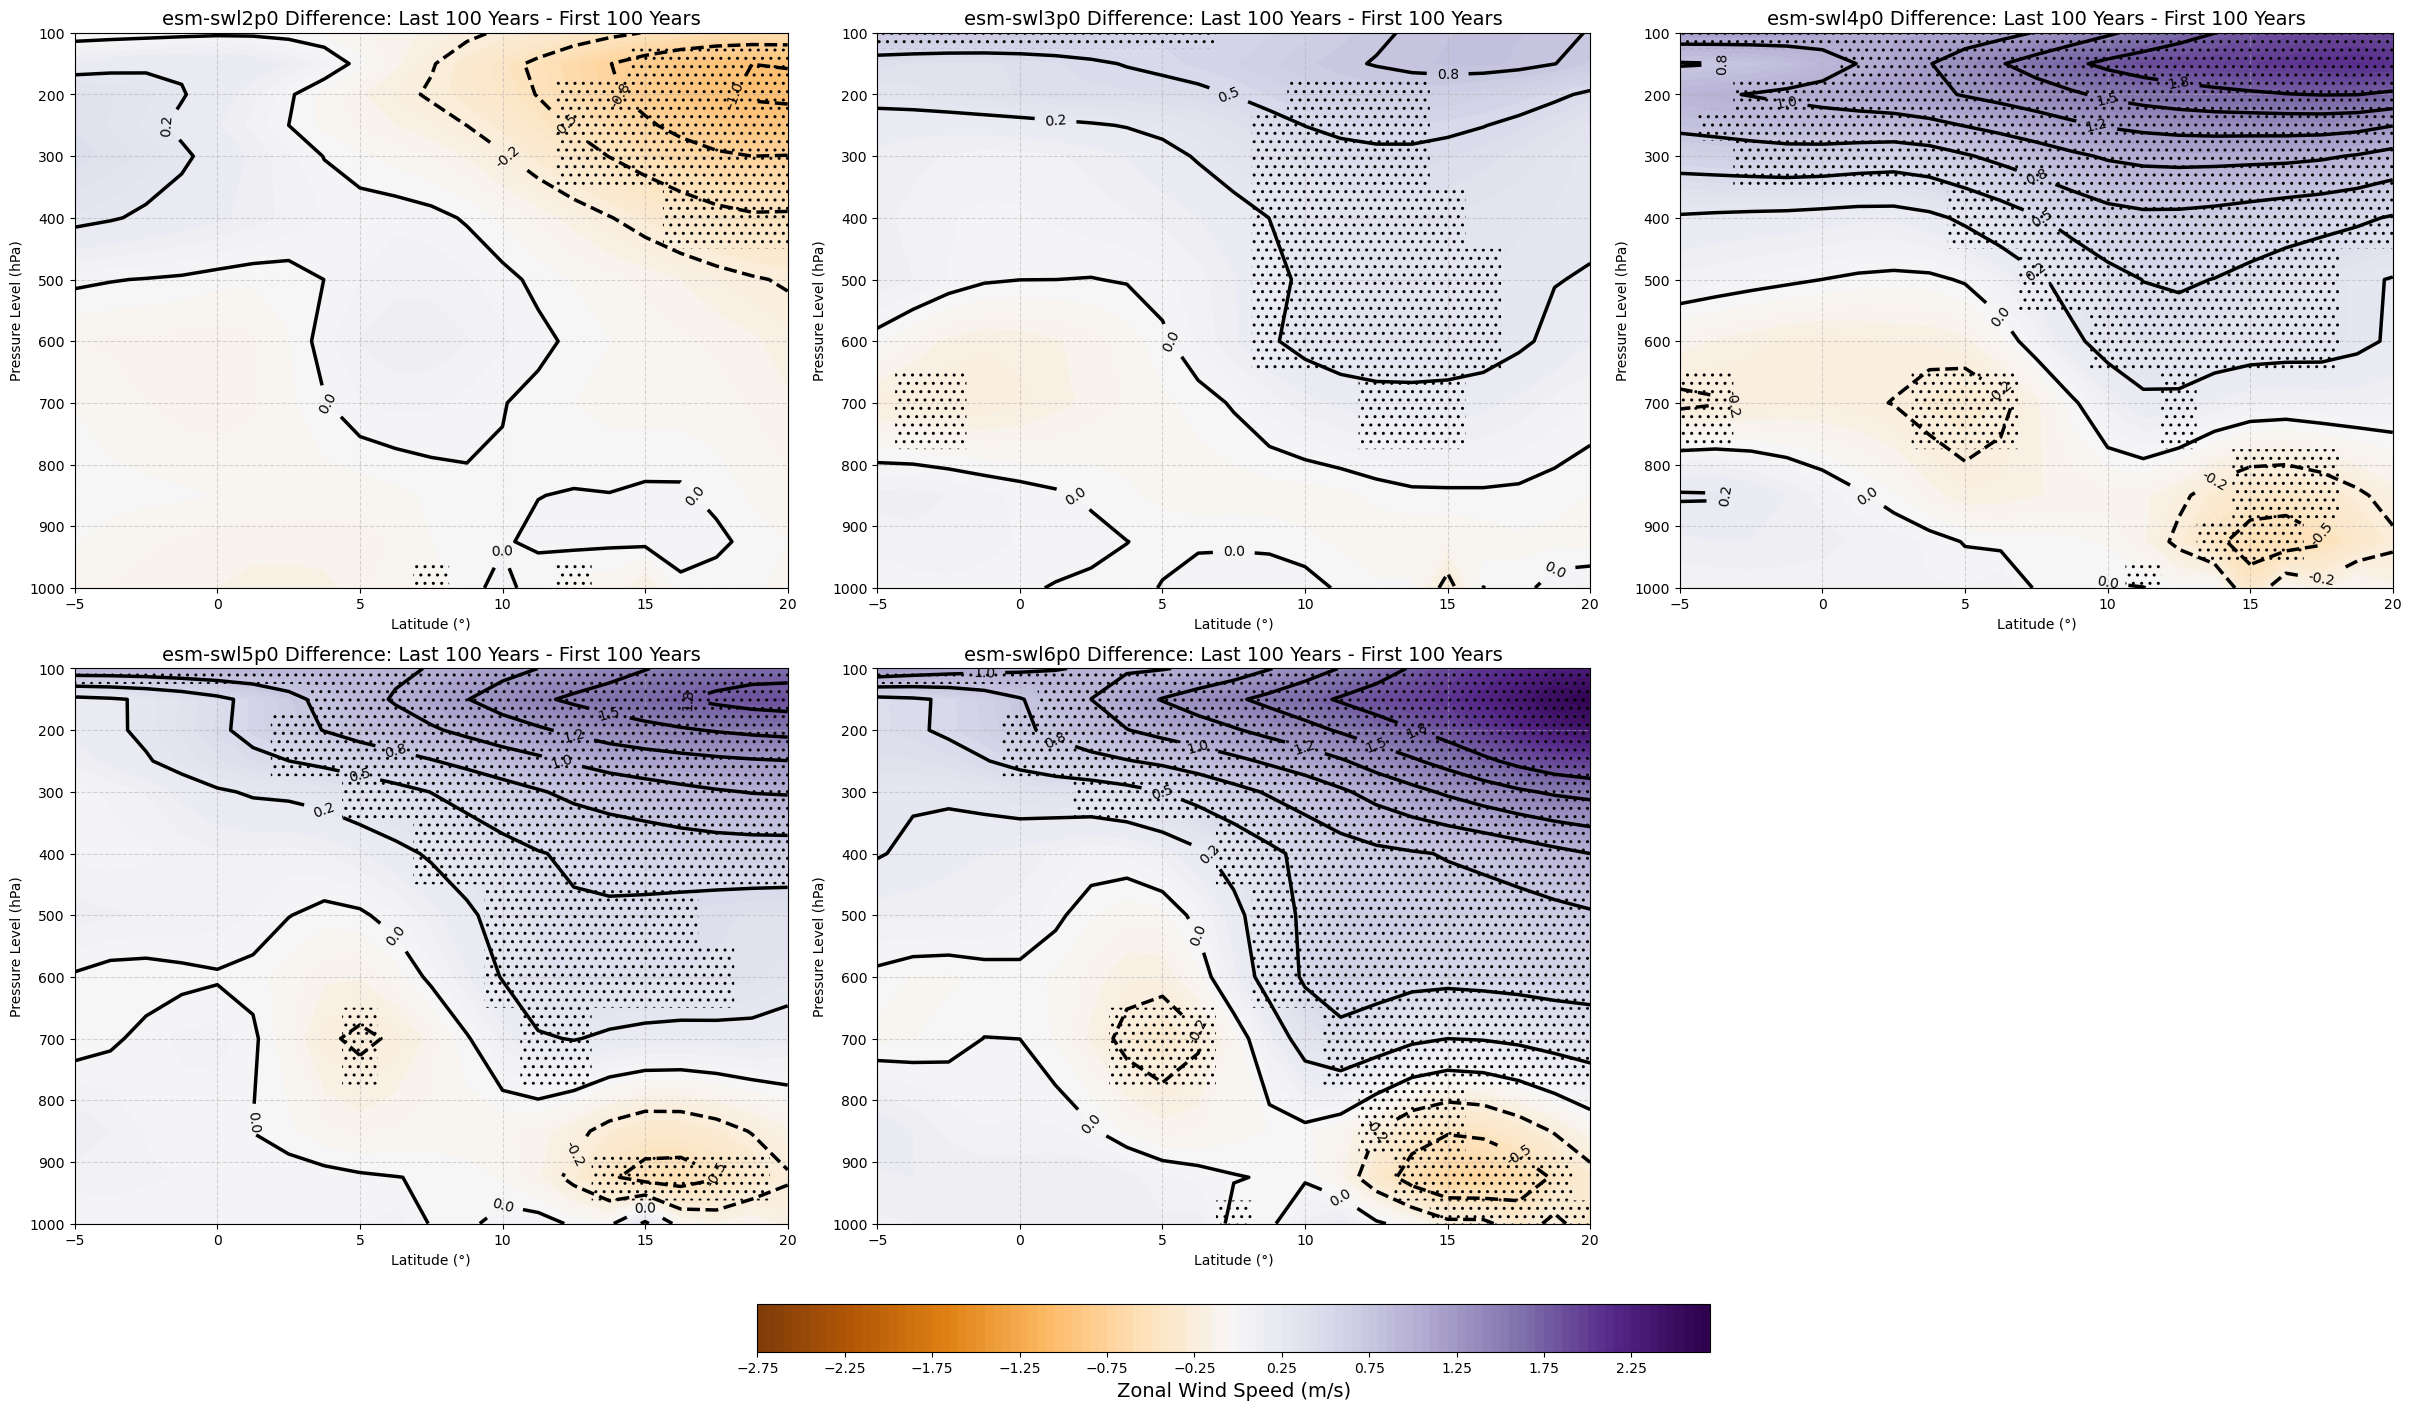

In [145]:
# Set extent
latmin, latmax = -5, 20
pmin, pmax = 100, 1000

# Colour palette parameters.
vmin = -2.75
vmax = 2.75
palette = 'PuOr'
cbar_label = 'Zonal Wind Speed (m/s)'

Save = True
filename = f'{path_figure}/net_zero_run_diff_cross_sections.png'

net_zero_cs(gwl_diff_dict, level_list, vmin, vmax, latmin, latmax, pmin, pmax, cbar_label,
            palette, Save, filename, p_val_dict)

## Climatology

### Implementation 3a (Plot)

In [206]:
def net_zero_maps(diff_data, first100yrs_data, level_list, vmin, vmax, cbar_label, palette, 
                  lonmin, lonmax, latmin, latmax, Save, filename):

    fig, axes = plt.subplots(2, 3, figsize=(24, 12), 
                             subplot_kw={'projection': ccrs.PlateCarree()}, 
                             constrained_layout=True)

    axes = axes.flatten()

    # Discrete colour levels
    levels = np.arange(vmin, vmax, 0.01)

    for i, scenario in enumerate(level_list):

        ### SHADE FOR DIFFERENCE BETWEEN LAST AND FIRST 100 YEARS###
        
        data = diff_data[scenario]['ua']

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('latitude', 'longitude')

        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)

        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

        contour = axes[i].contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette,
                                   extend='neither', transform=ccrs.PlateCarree())

        mm = axes[i].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin, vmax=vmax, 
                                transform=ccrs.PlateCarree(), cmap=palette)

        ### CONTOUR FOR FIRST 100 YEARS ###

        data = first100yrs_data[scenario]['ua']

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('latitude', 'longitude')

        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)
        
        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
       
        # Add contour lines every 1 m/s
        contour_lines = axes[i].contour(lon2d, lat2d, data_cyclic, levels=np.arange(-7, 7, 1),
                                        colors='black', linewidths=2.5)
        # Label contour lines
        # Set labels and axes
        axes[i].clabel(contour_lines, inline=True, fontsize=10, fmt='%.1f')
        
        axes[i].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i].coastlines()
        axes[i].gridlines(draw_labels=True)

        axes[i].set_title(f'{scenario} Difference: Last 100 Years - First 100 Years',
                          fontsize=14)

    # Turn off the last panel.
    for j in range(len(level_list), len(axes)):
        axes[j].axis('off')
    
    # One shared colourbar for all maps
    cbar = fig.colorbar(contour, ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, 
                        ticks=np.arange(vmin, vmax, 0.2))
    cbar.set_label(cbar_label, fontsize=14)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Actual Plot

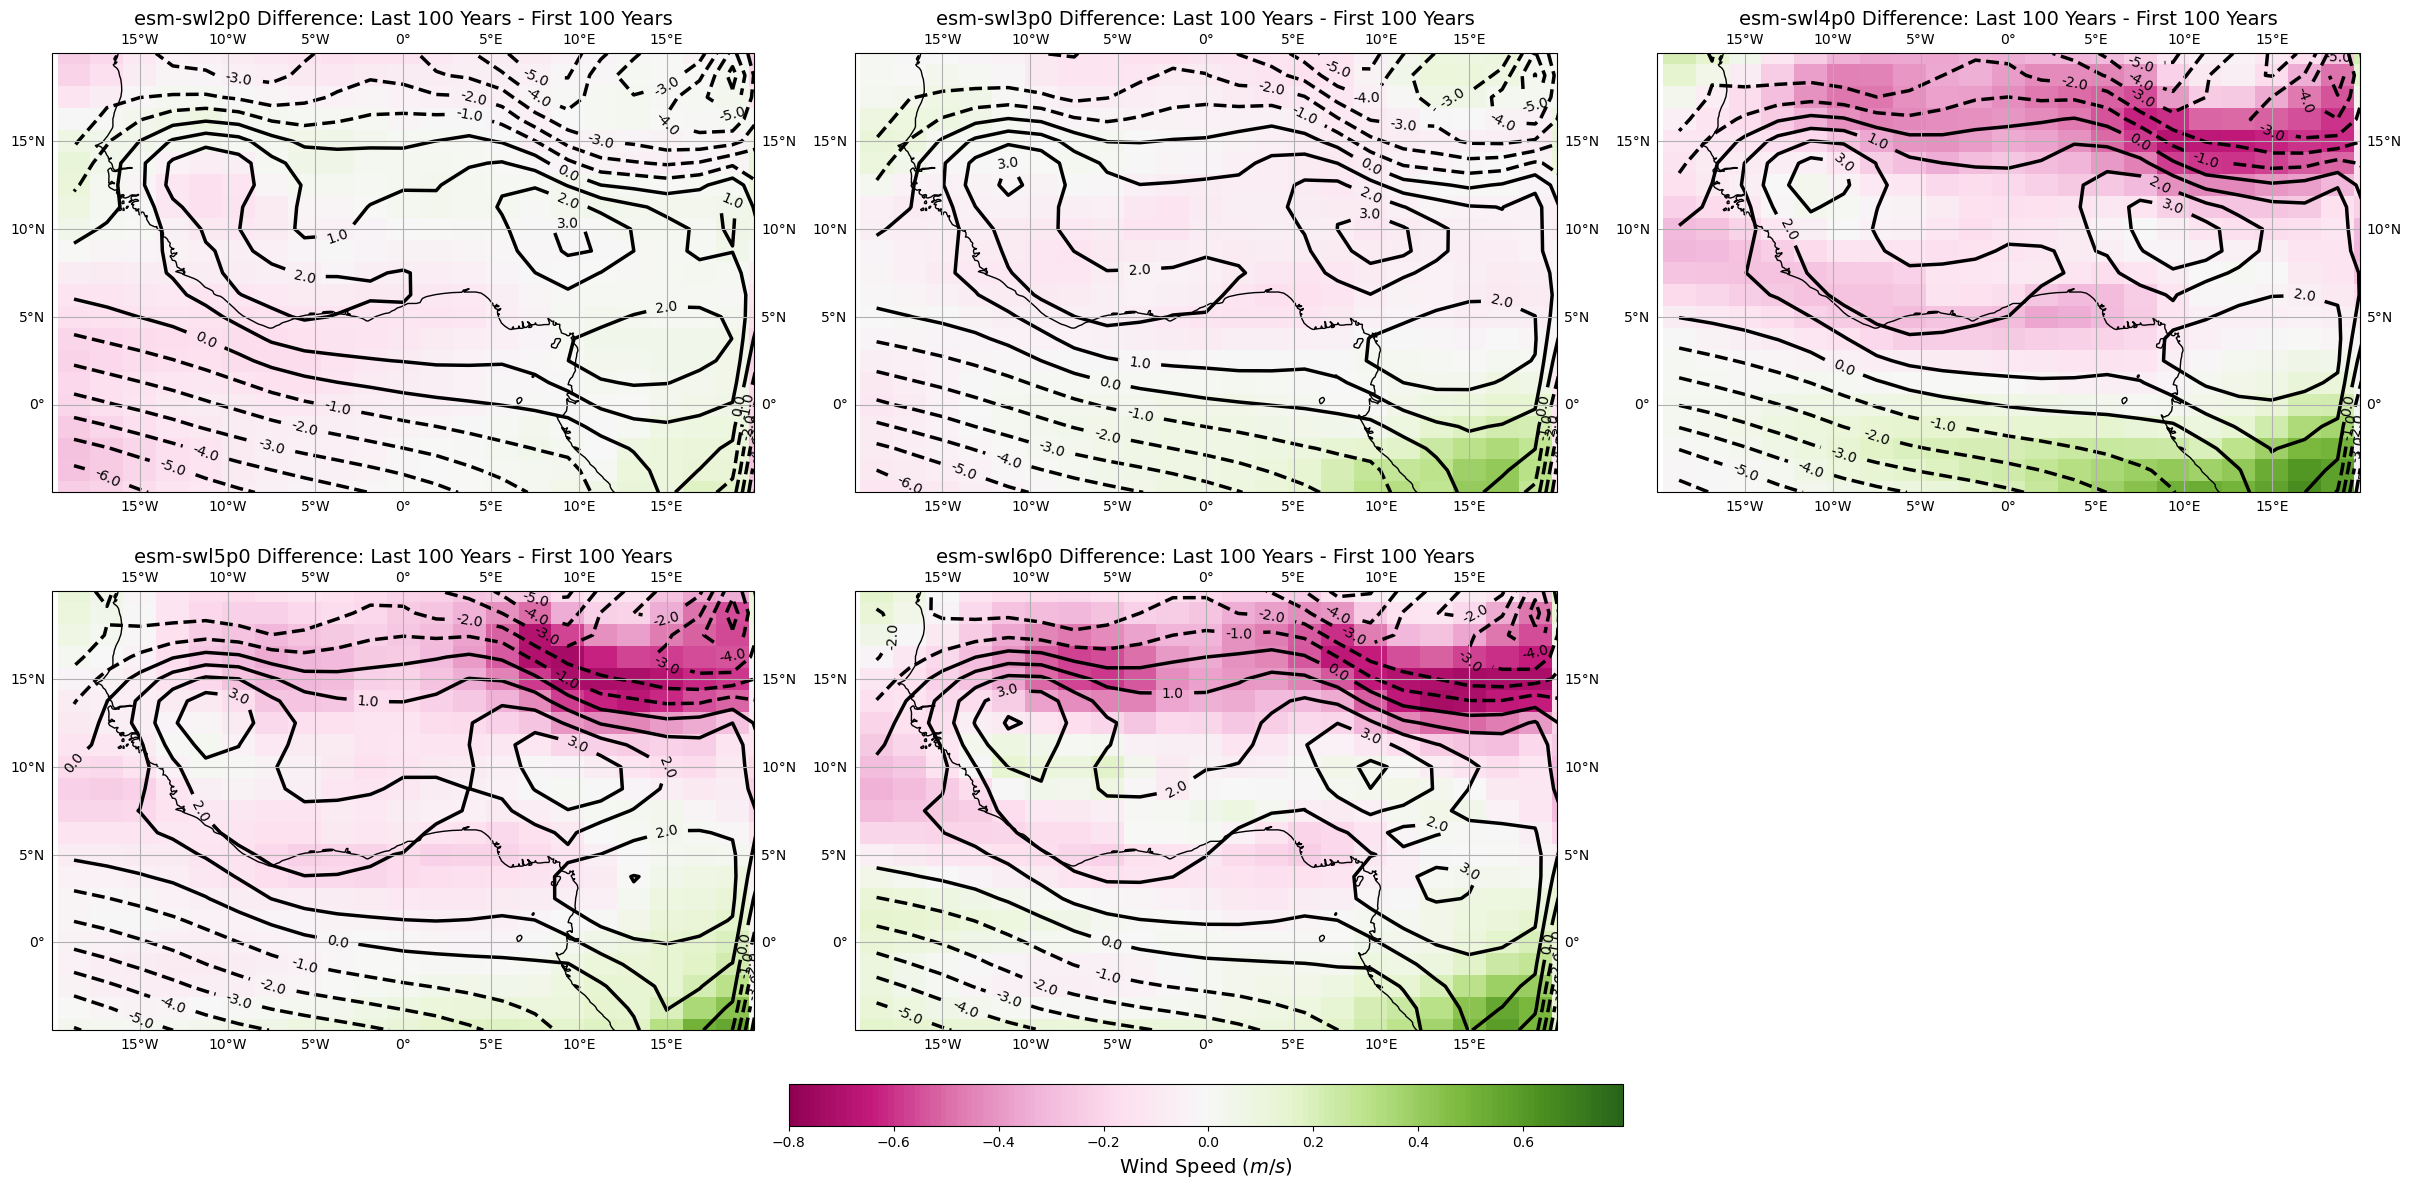

In [207]:
# Plot parameters
lonmin = -20
lonmax = 20
latmin = -5
latmax = 20

# Function parameters
unit = 'm/s'
palette = plt.cm.PiYG
reg = 'WAM'
seas = 'MJJAS'
bar_var = 'Wind Speed'

# Colourbar parameters
vmin = -0.8
vmax = 0.8
cbar_label = bar_var+' ($'+unit+'$)'
Save = True
filename = f'{path_figure}/net-zero_run_climatology.png'

# Plot
net_zero_maps(gwl_diff_dict_clim, gwl_first100yrs_dict, level_list, vmin, vmax, cbar_label, palette,
              lonmin, lonmax, latmin, latmax, Save, filename)